In [9]:
import os

print(os.listdir("../dataset"))

['student-mat.csv', 'student-por.csv', 'Students Performance Dataset.csv', 'Students_Grading_Dataset_Biased.csv', 'Student_performance_data _.csv', 'teaching_quality_dataset.csv', 'xAPI-Edu-Data.csv']


In [10]:
import pandas as pd
import nltk

nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\palla\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [11]:
# ==========================================
# LOAD TEACHING QUALITY DATASET
# ==========================================

import pandas as pd

df_teaching = pd.read_csv(
    "../dataset/teaching_quality_dataset.csv"
)

print("Dataset Shape:", df_teaching.shape)

df_teaching.head()

Dataset Shape: (2100, 15)


,student_id,course_id,instructor_id,feedback_score,textual_review,attendance_rate,assignment_submission_rate,quiz_avg_score,exam_avg_score,lms_logins_past_month,avg_session_duration_minutes,forum_participation_count,video_completion_rate,instructor_response_time,risk_level
0,S1000,MAT204,I003,1.9,The lecture was clear but pace was fast.,70,46,94,62,8,5,12,73,25,High
1,S1001,PHY110,I020,3.4,Very interactive and engaging class.,73,100,76,100,39,17,7,63,47,Medium
2,S1002,ECE301,I004,2.1,The lecture was clear but pace was fast.,53,88,87,55,16,34,12,51,13,High
3,S1003,PHY110,I018,3.6,"Too many assignments, difficult to manage.",61,96,34,71,16,9,15,54,54,Medium
4,S1004,PHY110,I006,4.3,The lecture was clear but pace was fast.,71,48,34,55,32,22,1,97,46,Medium


In [12]:
print(df_teaching.columns)

Index(['student_id', 'course_id', 'instructor_id', 'feedback_score',
       'textual_review', 'attendance_rate', 'assignment_submission_rate',
       'quiz_avg_score', 'exam_avg_score', 'lms_logins_past_month',
       'avg_session_duration_minutes', 'forum_participation_count',
       'video_completion_rate', 'instructor_response_time', 'risk_level'],
      dtype='str')


In [13]:
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

df_teaching['sentiment_score'] = (
    df_teaching['textual_review']
    .apply(lambda x: sia.polarity_scores(str(x))['compound'])
)

def sentiment_label(score):

    if score > 0.05:
        return "Positive"

    elif score < -0.05:
        return "Negative"

    else:
        return "Neutral"

df_teaching['sentiment'] = (
    df_teaching['sentiment_score']
    .apply(sentiment_label)
)

print(df_teaching['sentiment'].value_counts())

sentiment
Positive    1498
Negative     602
Name: count, dtype: int64


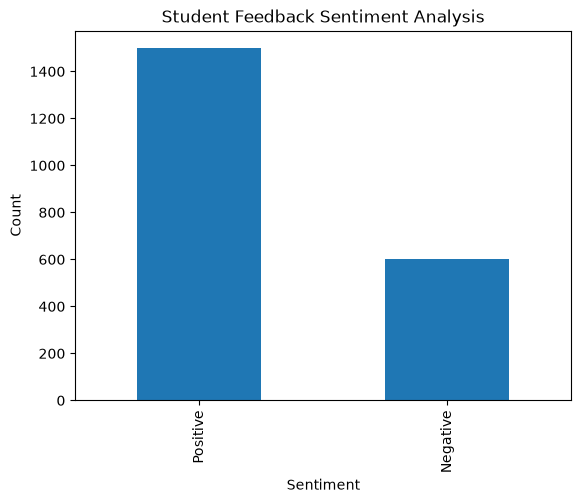

In [14]:
import matplotlib.pyplot as plt

df_teaching['sentiment'].value_counts().plot(
    kind='bar'
)

plt.title("Student Feedback Sentiment Analysis")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()